# LeetCode #83: Remove Duplicates from Sorted List

https://leetcode.com/problems/remove-duplicates-from-sorted-list/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| HashSet tracking | O(n) | O(n) | Track seen values in a set |
| **Single Pass (in-place) ★** | **O(n)** | **O(1)** | curr.next = curr.next.next when dup found |

---

## Understanding the Methods

### Brute Force (HashSet)
Keep a set of seen values. For each node, if value was seen, remove it. Works but O(n) extra space.

### Optimal: Single Pass ★
Since the list is sorted, duplicates are always adjacent. Walk with `curr`:
- If `curr.val == curr.next.val`: skip the next node by setting `curr.next = curr.next.next`. Do NOT advance curr — there may be more duplicates.
- Else: advance `curr = curr.next`.

Return head (unchanged pointer to first node).

**Constraints:**
* Number of nodes: [0, 300]
* Node values: [-100, 100]
* List is sorted in ascending order

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode DeleteDuplicates(ListNode head) {
        var curr = head;
        while (curr != null && curr.next != null) {
            if (curr.val == curr.next.val)
                curr.next = curr.next.next; // skip the duplicate
            else
                curr = curr.next;
        }
        return head;
    }
}

### Python

In [ ]:
class Solution:
    def deleteDuplicates(self, head):
        curr = head
        while curr and curr.next:
            if curr.val == curr.next.val:
                curr.next = curr.next.next
            else:
                curr = curr.next
        return head

### Go

In [ ]:
func deleteDuplicates(head *ListNode) *ListNode {
    curr := head
    for curr != nil && curr.Next != nil {
        if curr.Val == curr.Next.Val {
            curr.Next = curr.Next.Next
        } else {
            curr = curr.Next
        }
    }
    return head
}

### Rust

In [ ]:
impl Solution {
    pub fn delete_duplicates(mut head: Option<Box<ListNode>>) -> Option<Box<ListNode>> {
        let mut curr = head.as_mut();
        while let Some(node) = curr {
            while node.next.as_ref().map_or(false, |n| n.val == node.val) {
                node.next = node.next.take().and_then(|n| n.next);
            }
            curr = node.next.as_mut();
        }
        head
    }
}

## Example Scenarios

### 1. Common Case — Adjacent Duplicates
**Input:** `1 \to 1 \to 2 \to 3 \to 3`

curr = 1: `curr.val == curr.next.val` $\Rightarrow$ skip (link to 2). curr stays at 1. Next check: $1 \ne 2$ $\Rightarrow$ advance to 2. At 3: skip second 3. Result: $1 \to 2 \to 3$.

**Why it’s useful:** Exercises both branches (skip and advance) in alternation.

### 2. Slightly Complex — Triple and Quadruple Duplicates
**Input:** `1 \to 1 \to 1 \to 2 \to 2 \to 2 \to 2 \to 3`

curr = 1: skip twice (past two extra 1s), then advance to 2. curr = 2: skip three times (past three extra 2s), then advance to 3. The key: curr does NOT advance after a skip, so it catches chains of duplicates one removal at a time.

**Why it’s tricky:** Multiple consecutive duplicates require multiple skip operations before curr advances. Each skip removes exactly one duplicate node.

### 3. Edge Case: Time Factor — 300 Identical Nodes
**Input:** `100 \to 100 \to \ldots \to 100` (300 nodes)

curr stays at the first node for all 299 iterations, each time skipping one duplicate. curr never advances. The loop runs $n - 1 = 299$ times, each doing $O(1)$ work. Total: $O(n)$.

**Why it’s tricky:** Worst case for the skip path. curr.next shrinks from 299 hops to null in 299 steps. The loop terminates because `curr.next` eventually becomes null.

### 4. Edge Case: Space Factor — Empty and Single-Node Lists
**Input:** `head = null` and `head = 42`

Both cause the while loop to not execute (condition `curr != null && curr.next != null` fails). Returns head unchanged. Only 1 pointer variable (curr) used. Unlike problem \#82, no dummy node is needed because the head node is always kept.

**Why it’s tricky:** $O(1)$ space with no auxiliary structures. Tests the zero-iteration edge.

### 5. Almost-Impossible but Plausible — Boundary Values, 300 Nodes
**Input:** $(-100)^{\times 100} \to 0^{\times 100} \to 100^{\times 100}$ (300 nodes total)

Three long chains of duplicates at the min ($-100$), zero ($0$), and max ($100$) values. 297 nodes skipped, 3 kept. In GC languages, skipped nodes are collected; in C/Rust, they must be freed explicitly to avoid leaks.

**Why it’s tricky:** Tests boundary values ($-100$ and $100$). In a real interview, the interviewer may ask about memory management of the removed nodes.


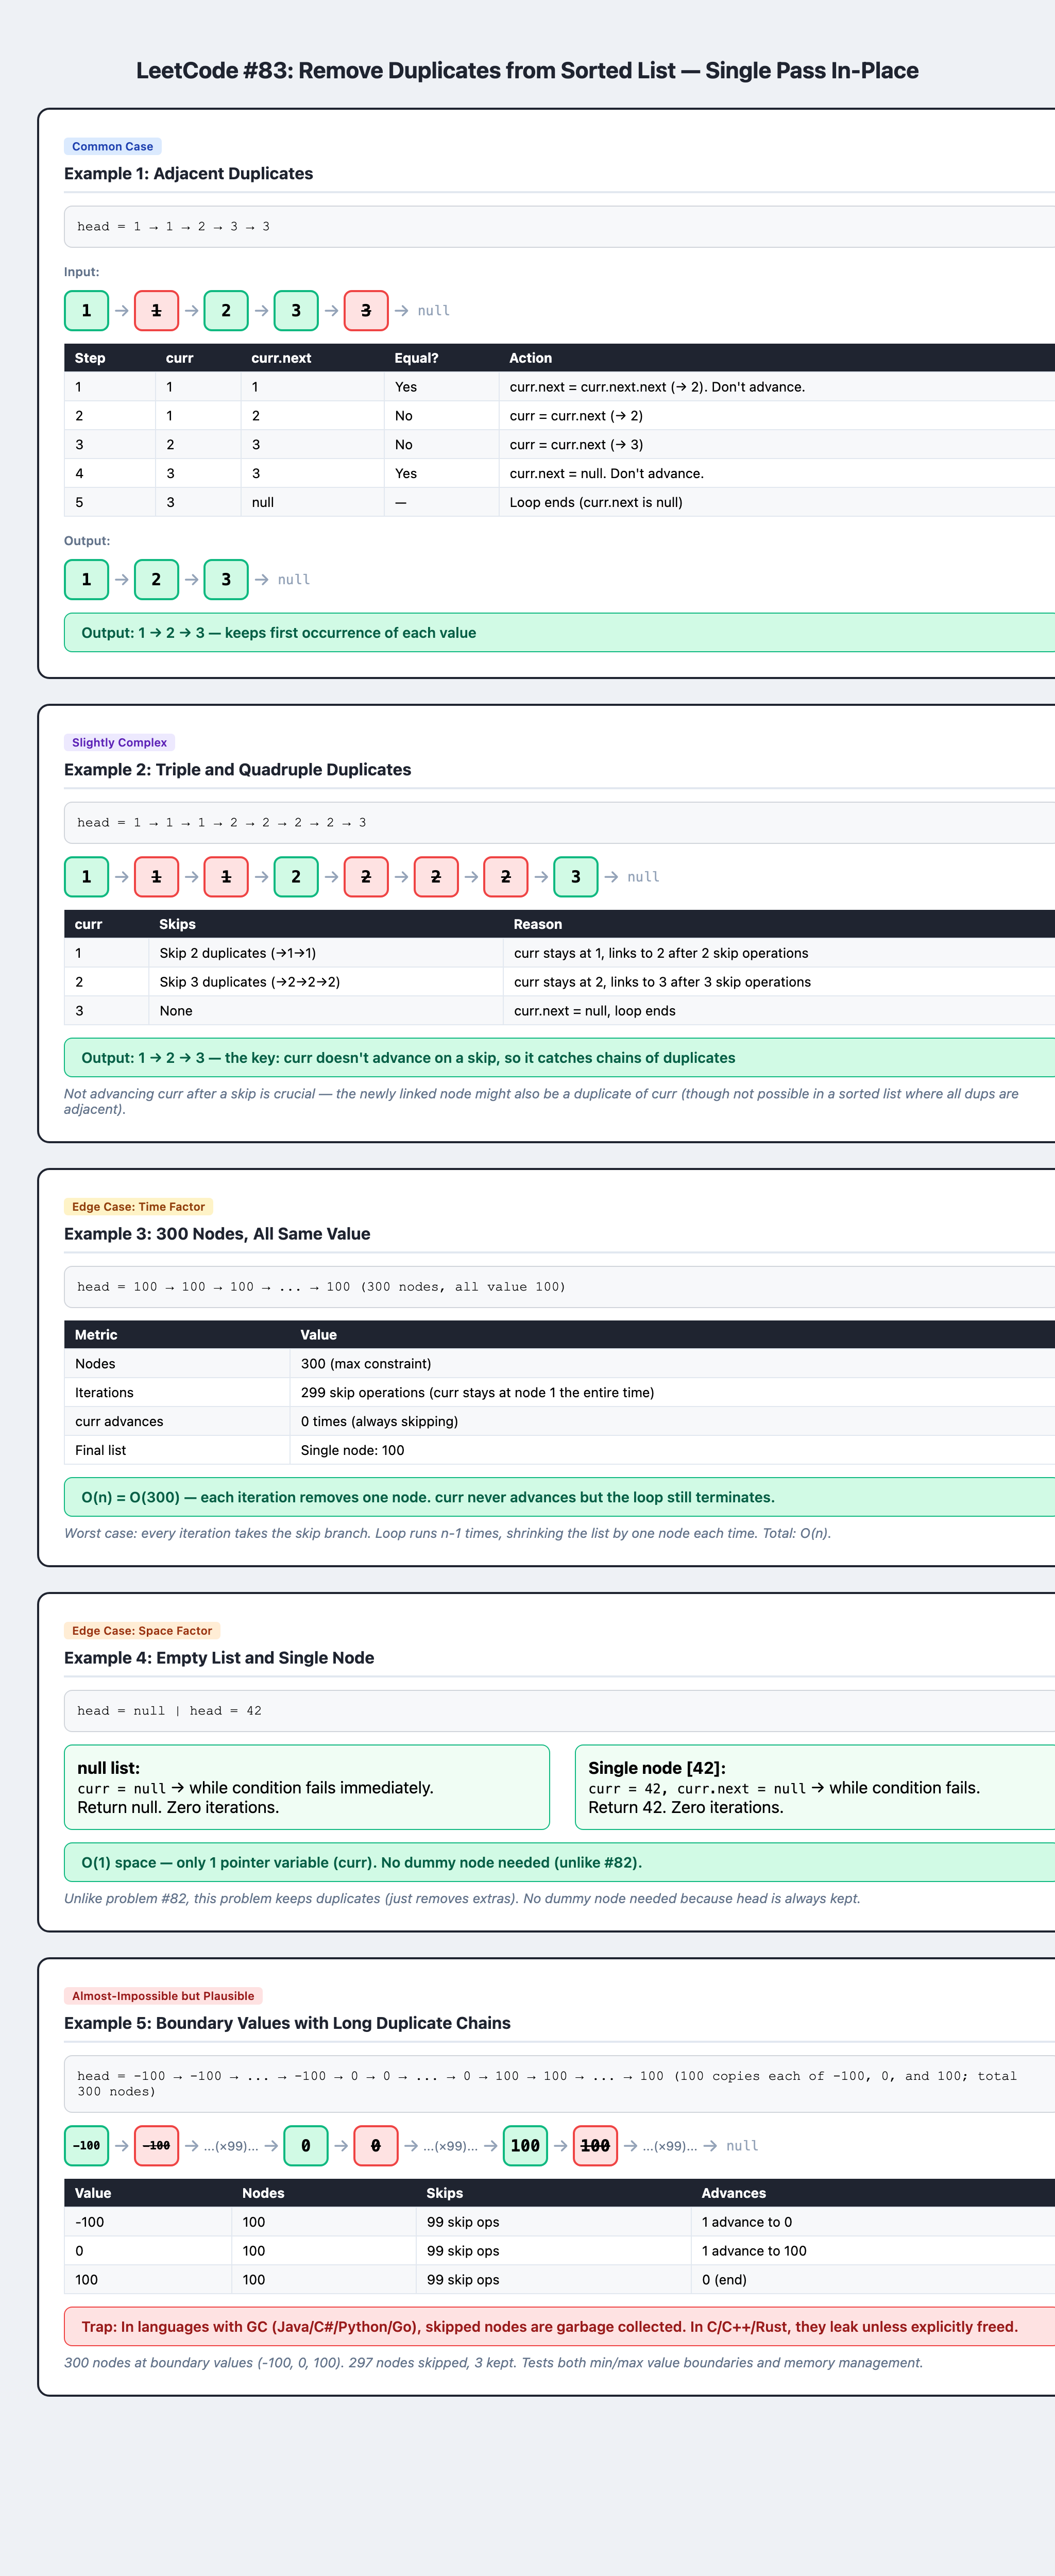